In [3]:
"""
To build a robust regression pipeline that predicts used car prices by extracting features from technical specifications and categorical data. 
This project focuses on end-to-end reproducibility using Scikit-Learn Pipelines and custom transformers.
"""

'\nTo build a robust regression pipeline that predicts used car prices by extracting features from technical specifications and categorical data. \nThis project focuses on end-to-end reproducibility using Scikit-Learn Pipelines and custom transformers.\n'

In [29]:
# importing relevant libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate

In [2]:
# importing dataset

df = pd.read_csv(r"car details v4.csv")

print(df.head(10))
print("\n\n")
print(df.describe().T)
print("\n\n")
print(df.shape)
print("\n\n")
print(df.isnull().sum())


            Make                                 Model    Price  Year  \
0          Honda                   Amaze 1.2 VX i-VTEC   505000  2017   
1  Maruti Suzuki                       Swift DZire VDI   450000  2014   
2        Hyundai                  i10 Magna 1.2 Kappa2   220000  2011   
3         Toyota                              Glanza G   799000  2019   
4         Toyota       Innova 2.4 VX 7 STR [2016-2020]  1950000  2018   
5  Maruti Suzuki                              Ciaz ZXi   675000  2017   
6  Mercedes-Benz                  CLA 200 Petrol Sport  1898999  2015   
7            BMW                  X1 xDrive20d M Sport  2650000  2017   
8          Skoda  Octavia 1.8 TSI Style Plus AT [2017]  1390000  2017   
9         Nissan                        Terrano XL (D)   575000  2015   

   Kilometer Fuel Type Transmission    Location   Color   Owner Seller Type  \
0      87150    Petrol       Manual        Pune    Grey   First   Corporate   
1      75000    Diesel       Manual   

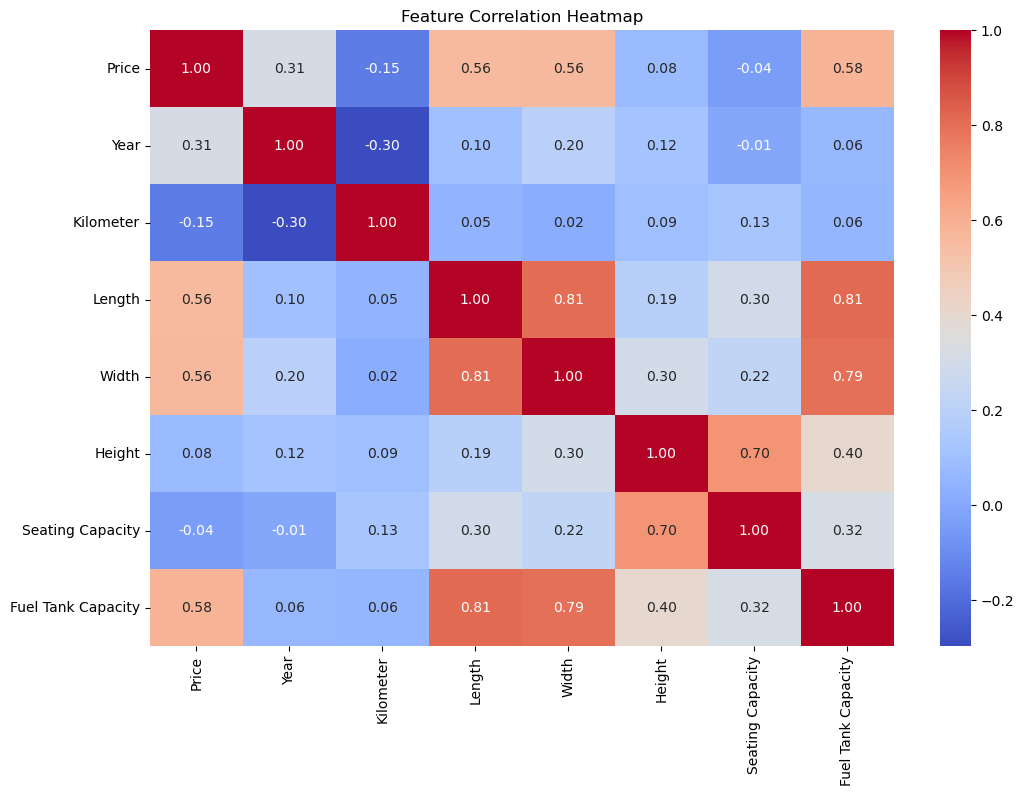

In [11]:
# further eda

plt.figure(figsize = (12, 8))

numerical_cols = df.select_dtypes(include = [np.number]).columns 
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()



In [15]:
# top numerical features Check
print(f"Correlation of numerical columns in subject of target variable [Price]: \n\n{corr_matrix["Price"].sort_values(ascending = False)}")



Correlation of numerical columns in subject of target variable [Price]: 

Price                 1.000000
Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Height                0.075080
Seating Capacity     -0.038524
Kilometer            -0.150825
Name: Price, dtype: float64


In [4]:
# Preprocessing 
"""
We implement a ColumnTransformer to handle diverse data types. 
Numerical features are imputed with medians and standardized, while categorical features undergo one-hot encoding with unknown-label handling. 
A custom FunctionTransformer is integrated at the start of the pipeline to programmatically clean technical strings (e.g., "cc", "bhp") directly from the raw input.
"""



'\nWe implement a ColumnTransformer to handle diverse data types. \nNumerical features are imputed with medians and standardized, while categorical features undergo one-hot encoding with unknown-label handling. \nA custom FunctionTransformer is integrated at the start of the pipeline to programmatically clean technical strings (e.g., "cc", "bhp") directly from the raw input.\n'

In [25]:
# Extracting Numerical Values from Columns: Max Power and Max Torque

def engineering_specs_transformer(df):
    df = df.copy()
    
    power_regex = r'(\d+\.?\d*)\s*bhp\s*@\s*(\d+\.?\d*)'
    power_data = df['Max Power'].str.extract(power_regex).astype(float)
    df['Power_Val'] = power_data[0]
    df['Power_RPM'] = power_data[1]
    
    torque_regex = r'(\d+\.?\d*)\s*Nm\s*@\s*(\d+\.?\d*)'
    torque_data = df['Max Torque'].str.extract(torque_regex).astype(float)
    df['Torque_Val'] = torque_data[0]
    df['Torque_RPM'] = torque_data[1]

    df['Engine_CC'] = df['Engine'].str.extract(r'(\d+)').astype(float)
    
    cols_to_drop = ['Max Power', 'Max Torque', 'Engine']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df
#print(engineering_specs_transformer(df).head(10))
df_cleaned = engineering_specs_transformer(df)
print(df_cleaned.head(10))

            Make                                 Model    Price  Year  \
0          Honda                   Amaze 1.2 VX i-VTEC   505000  2017   
1  Maruti Suzuki                       Swift DZire VDI   450000  2014   
2        Hyundai                  i10 Magna 1.2 Kappa2   220000  2011   
3         Toyota                              Glanza G   799000  2019   
4         Toyota       Innova 2.4 VX 7 STR [2016-2020]  1950000  2018   
5  Maruti Suzuki                              Ciaz ZXi   675000  2017   
6  Mercedes-Benz                  CLA 200 Petrol Sport  1898999  2015   
7            BMW                  X1 xDrive20d M Sport  2650000  2017   
8          Skoda  Octavia 1.8 TSI Style Plus AT [2017]  1390000  2017   
9         Nissan                        Terrano XL (D)   575000  2015   

   Kilometer Fuel Type Transmission    Location   Color   Owner  ...  Length  \
0      87150    Petrol       Manual        Pune    Grey   First  ...  3990.0   
1      75000    Diesel       Manual 

In [26]:
# Numeric Features and Categorical Features
numeric_features = [
    'Year', 'Kilometer', 'Engine_CC', 
    'Power_Val', 'Power_RPM', 
    'Torque_Val', 'Torque_RPM', 
    'Length', 'Width', 'Height', 'Fuel Tank Capacity'
]

# 2. Categorical Features remain the same
categorical_features = [
    'Make', 'Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain'
]

print(df_cleaned[categorical_features])
print(df_cleaned[numeric_features])

               Make Fuel Type Transmission   Owner Seller Type Drivetrain
0             Honda    Petrol       Manual   First   Corporate        FWD
1     Maruti Suzuki    Diesel       Manual  Second  Individual        FWD
2           Hyundai    Petrol       Manual   First  Individual        FWD
3            Toyota    Petrol       Manual   First  Individual        FWD
4            Toyota    Diesel       Manual   First  Individual        RWD
...             ...       ...          ...     ...         ...        ...
2054       Mahindra    Diesel       Manual   First  Individual        FWD
2055        Hyundai    Petrol       Manual  Second  Individual        FWD
2056           Ford    Petrol       Manual   First  Individual        FWD
2057            BMW    Diesel    Automatic   First  Individual        RWD
2058       Mahindra    Diesel       Manual   First  Individual        RWD

[2059 rows x 6 columns]
      Year  Kilometer  Engine_CC  Power_Val  Power_RPM  Torque_Val  \
0     2017      8

In [27]:
# Pipelines - Preprocessing Step
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])


final_pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(engineering_specs_transformer)),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [39]:
X = df.drop(columns = 'Price')
y = df["Price"]

kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
    'mape' : 'neg_mean_absolute_percentage_error',
    'mse' : 'neg_mean_squared_error',
    'rmse' : 'neg_root_mean_squared_error'    
}

cv_results = cross_validate(final_pipeline, X, y, cv = kf, scoring = scoring, n_jobs = -1)
mae_scores = -cv_results['test_mae']
r2_scores = cv_results['test_r2']
mape_scores = -cv_results['test_mape']
mse_scores = -cv_results['test_mse']
rmse_scores = -cv_results['test_rmse']

print(f"Average R2 Score: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"Average MAE: {mae_scores.mean():,.2f} (+/- {mae_scores.std():,.2f})")
print(f"\nMean Absolute Percentage Error: \n {mape_scores.mean():.4f}")
print(f"\nMean Squared Error: \n {mse_scores.mean():.4f}")
print(f"\nRoot Mean Squared Error: \n {rmse_scores.mean():.4f}")

Average R2 Score: 0.8740 (+/- 0.0300)
Average MAE: 286,876.39 (+/- 24,645.00)

Mean Absolute Percentage Error: 
 0.1751

Mean Squared Error: 
 757064884703.1758

Root Mean Squared Error: 
 856555.5068


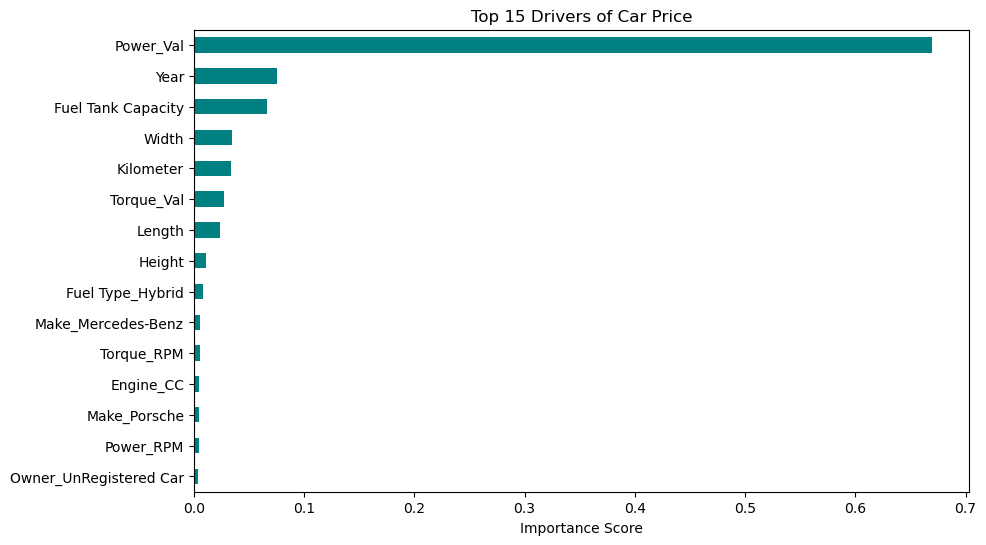

In [40]:
final_pipeline.fit(X, y)

ohe_features = final_pipeline.named_steps['preprocessor']\
               .transformers_[1][1]\
               .named_steps['ohe']\
               .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numeric_features, ohe_features])

importances = final_pipeline.named_steps['regressor'].feature_importances_

feat_importances = pd.Series(importances, index = all_feature_names)

plt.figure(figsize=(10,6))
feat_importances.nlargest(15).plot(kind='barh', color='teal')
plt.title("Top 15 Drivers of Car Price")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis() # Highest at the top
plt.show()


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results_df.head(10))



       Actual   Predicted
1298  4800000  4823489.99
591    825000   902199.99
1318   695000   559299.99
1067   950000   994469.99
29     819999   795549.65
1058   310000   371790.00
712   1000000   963659.97
453   1998999  2626049.98
1646   850000  1513159.98
757   3950000  5113609.96


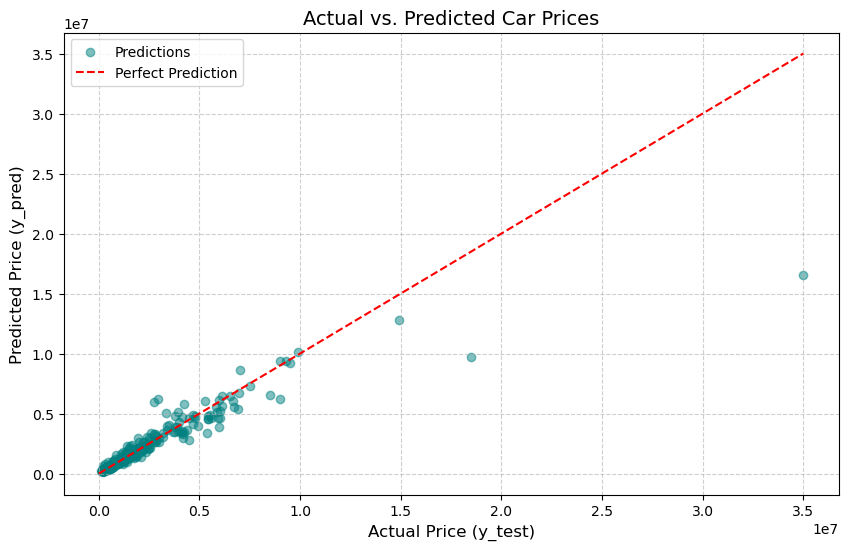

R Score: 
0.8225

Mean Absolute Error: 
299060.6473


In [49]:
plt.figure(figsize = (10, 6))
plt.scatter(y_test, y_pred, alpha = 0.5, color = 'teal', label = 'Predictions')

limit = max(max(y_test), max(y_pred))
plt.plot([0, limit], [0, limit], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Car Prices', fontsize=14)
plt.xlabel('Actual Price (y_test)', fontsize=12)
plt.ylabel('Predicted Price (y_pred)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R Score: \n{r2:.4f}")
print(f"\nMean Absolute Error: \n{mae:.4f}")

In [53]:
# Running SearchGridCV - Hyper parameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator = final_pipeline, 
    param_grid = param_grid, 
    cv = kf, 
    scoring = 'r2', 
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X, y)

print(f"Best Score (R2): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# 4. Use the best version for your final model
final_tuned_pipeline = grid_search.best_estimator_



Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Score (R2): 0.8771
Best Parameters: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}


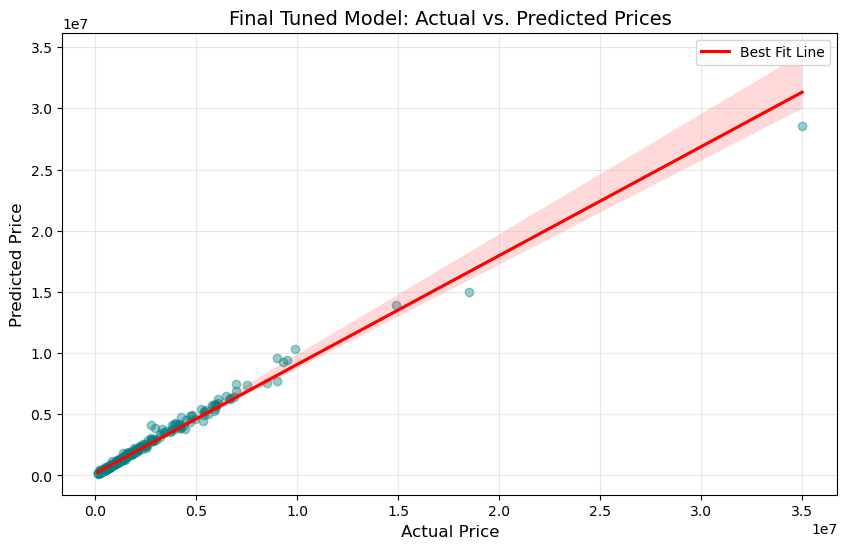

Tuned R2 Score: 0.9765
Tuned MAE: 111,125.31


In [54]:
# Visualising Predictive Accuracy of GridSearchCV Model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.regplot(x = y_test, y = y_pred_tuned, 
            scatter_kws = {'alpha':0.4, 'color':'teal'}, 
            line_kws = {'color':'red', 'label':'Best Fit Line'})

plt.title('Final Tuned Model: Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Tuned R2 Score: {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned MAE: {mean_absolute_error(y_test, y_pred_tuned):,.2f}")
